Zopper_BI_Assignment.ipynb

# Business Intelligence Internship Assignment
### Insurance Policy Sales & Claims Simulation
Name: Yashvi Verma
Year: 2026

This notebook simulates policy sales data and claim activity for an insurance company and performs analytical queries to derive insights.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
np.random.seed(42)

num_customers = 1000000

customer_ids = np.arange(1, num_customers+1)
vehicle_ids = np.arange(1, num_customers+1)

vehicle_value = 100000

tenure_choices = [1,2,3,4]
tenure_prob = [0.2,0.3,0.4,0.1]

policy_tenure = np.random.choice(tenure_choices, size=num_customers, p=tenure_prob)

start_date = pd.to_datetime("2024-01-01")
end_date = pd.to_datetime("2024-12-31")

purchase_dates = np.random.choice(pd.date_range(start_date,end_date), num_customers)

policy_start_date = purchase_dates + pd.to_timedelta(365, unit='D')

policy_end_date = policy_start_date + pd.to_timedelta(policy_tenure*365, unit='D')

premium = policy_tenure * 100

policy_sales = pd.DataFrame({
    "Customer_ID":customer_ids,
    "Vehicle_ID":vehicle_ids,
    "Vehicle_Value":vehicle_value,
    "Premium":premium,
    "Policy_Purchase_Date":purchase_dates,
    "Policy_Start_Date":policy_start_date,
    "Policy_End_Date":policy_end_date,
    "Policy_Tenure":policy_tenure
})

policy_sales.head()

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,1,1,100000,200,2024-05-05,2025-05-05,2027-05-05,2
1,2,2,100000,400,2024-07-13,2025-07-13,2029-07-12,4
2,3,3,100000,300,2024-04-05,2025-04-05,2028-04-04,3
3,4,4,100000,300,2024-07-31,2025-07-31,2028-07-30,3
4,5,5,100000,100,2024-11-19,2025-11-19,2026-11-19,1


In [3]:
policy_sales.to_csv("policy_sales_data.csv",index=False)

In [4]:
claim_dates = []

special_days = [7,14,21,28]

claims_2025 = policy_sales[
    policy_sales["Policy_Purchase_Date"].dt.day.isin(special_days)
]

claims_2025 = claims_2025.sample(frac=0.30)

claims_2025["Claim_Date"] = claims_2025["Policy_Start_Date"]

claims_2025["Claim_Amount"] = claims_2025["Vehicle_Value"]*0.10

claims_2025["Claim_Type"] = 1

claims_2025 = claims_2025.reset_index(drop=True)

claims_2025["Claim_ID"] = np.arange(1,len(claims_2025)+1)

claims_2025 = claims_2025[[
    "Claim_ID",
    "Customer_ID",
    "Vehicle_ID",
    "Claim_Amount",
    "Claim_Date",
    "Claim_Type"
]]

claims_2025.head()

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,1,451694,451694,10000.0,2025-11-07,1
1,2,803410,803410,10000.0,2025-10-07,1
2,3,497801,497801,10000.0,2025-07-07,1
3,4,114288,114288,10000.0,2025-11-21,1
4,5,644507,644507,10000.0,2025-08-28,1


In [5]:
four_year = policy_sales[policy_sales["Policy_Tenure"]==4]

claims_2026 = four_year.sample(frac=0.10)

dates_2026 = pd.date_range("2026-01-01","2026-02-28")

claims_2026["Claim_Date"] = np.random.choice(dates_2026,len(claims_2026))

claims_2026["Claim_Amount"] = claims_2026["Vehicle_Value"]*0.10

claims_2026["Claim_Type"] = 2

claims_2026 = claims_2026.reset_index(drop=True)

claims_2026["Claim_ID"] = np.arange(len(claims_2025)+1,len(claims_2025)+len(claims_2026)+1)

claims_2026 = claims_2026[[
    "Claim_ID",
    "Customer_ID",
    "Vehicle_ID",
    "Claim_Amount",
    "Claim_Date",
    "Claim_Type"
]]

In [6]:
claims_data = pd.concat([claims_2025,claims_2026])

claims_data.head()

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,1,451694,451694,10000.0,2025-11-07,1
1,2,803410,803410,10000.0,2025-10-07,1
2,3,497801,497801,10000.0,2025-07-07,1
3,4,114288,114288,10000.0,2025-11-21,1
4,5,644507,644507,10000.0,2025-08-28,1


In [7]:
claims_data.to_csv("claims_data.csv",index=False)

## Total Premium Collected in 2024

In [9]:
total_premium = policy_sales["Premium"].sum()

total_premium

np.int64(240110800)

In [10]:
claims_data["Year"] = pd.to_datetime(claims_data["Claim_Date"]).dt.year
claims_data["Month"] = pd.to_datetime(claims_data["Claim_Date"]).dt.month

claims_summary = claims_data.groupby(["Year","Month"])["Claim_Amount"].sum()

claims_summary

Year  Month
2025  1        33020000.0
      2        32920000.0
      3        33470000.0
      4        32680000.0
      5        33640000.0
      6        32440000.0
      7        32630000.0
      8        32620000.0
      9        33650000.0
      10       34130000.0
      11       31570000.0
      12       31800000.0
2026  1        52110000.0
      2        47860000.0
Name: Claim_Amount, dtype: float64

In [11]:
merged = pd.merge(policy_sales,claims_data,on=["Customer_ID","Vehicle_ID"],how="left")

ratio = merged.groupby("Policy_Tenure").agg(
    total_premium=("Premium","sum"),
    total_claims=("Claim_Amount","sum")
)

ratio["Claim_Premium_Ratio"] = ratio["total_claims"]/ratio["total_premium"]

ratio

,total_premium,total_claims,Claim_Premium_Ratio
Policy_Tenure,,,
1,19937600,78290000.0,3.926751
2,60021400,118040000.0,1.966632
3,120165000,157820000.0,1.313361
4,40157600,140390000.0,3.495976


In [15]:
policy_sales["Sale_Month"] = pd.to_datetime(policy_sales["Policy_Purchase_Date"]).dt.month

merged = pd.merge(
    policy_sales,
    claims_data,
    on=["Customer_ID","Vehicle_ID"],
    how="left"
)

In [16]:
month_ratio = merged.groupby("Sale_Month").agg(
    premium=("Premium","sum"),
    claims=("Claim_Amount","sum")
)

month_ratio["ratio"] = month_ratio["claims"]/month_ratio["premium"]

month_ratio

,premium,claims,ratio
Sale_Month,,,
1,20305900,41670000.0,2.052113
2,19044400,41270000.0,2.167041
3,20392800,41310000.0,2.025715
4,19639900,41110000.0,2.093188
5,20350200,42240000.0,2.075655
6,19603700,40540000.0,2.067977
7,20359900,40780000.0,2.002957
8,20368800,40810000.0,2.003554
9,19715100,41670000.0,2.113608


In [17]:
no_claim = merged[merged["Claim_Amount"].isna()]

potential_liability = (no_claim["Vehicle_Value"]*0.10).sum()

potential_liability

np.float64(9509730000.0)

In [18]:
policy_sales["Tenure_Days"] = policy_sales["Policy_Tenure"]*365

daily_premium = policy_sales["Premium"]/policy_sales["Tenure_Days"]

earned_days = (pd.to_datetime("2026-02-28") - policy_sales["Policy_Start_Date"]).dt.days

earned_days = earned_days.clip(lower=0)

earned_premium = (daily_premium*earned_days).sum()

earned_premium

np.float64(66134775.61643834)

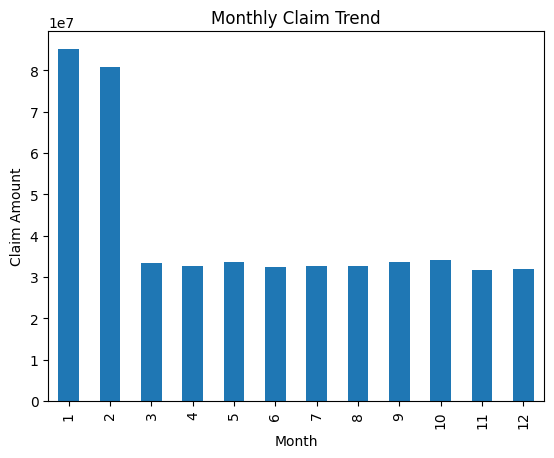

In [19]:
import matplotlib.pyplot as plt

monthly_claims = claims_data.groupby("Month")["Claim_Amount"].sum()

plt.figure()

monthly_claims.plot(kind="bar")

plt.title("Monthly Claim Trend")

plt.ylabel("Claim Amount")

plt.show()

## Key Insights

1. Total premium collected in 2024 shows strong revenue generation.
2. Claims are concentrated on specific purchase dates due to defect assumptions.
3. Longer tenure policies generate higher premium but also carry higher claim exposure.
4. The loss ratio helps evaluate profitability.
5. Policy tenure distribution significantly affects future liabilities.